# Parameters

In [1]:
from pathlib import Path
import sys 

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import (
    mcwf_dt_from_scales,
    omega_c,
    scaled_N_Gamma,
)
from common.utils.phases import default_three_phase_protocol
from post_analysis import compute_mfe_residuals
from parser.moments import MomentSeries, SimulationMetadata


%reload_ext autoreload
%autoreload 2

output_dir = Path("../output")

### Parameters

In [11]:
from common.utils.parameters import Gamma_from_twa

# common fixed
num_snapshots=500
# param
dN = 0
Ni = [50,50]
ntraj = 1000
# Model and parameters
Gamma = Gamma_from_twa(N=sum(Ni))
Omega_1 = 0.388393
Omega_2 = 0.274636
Omega0 = (Omega_1 + Omega_2)/2
omega_i = [Omega_1 / Omega0]
delta0 = 0.1
dt = mcwf_dt_from_scales(Omega0, delta0, sum(Ni), Gamma)

# protocol durations
durations = (100.0, 100.0, 10.0)

phase_protocol = default_three_phase_protocol(
    durations=durations,
    delta0=delta0,
    Omega0=Omega0,
)
phase_protocol_ramp = default_three_phase_protocol(
    durations=durations,
    delta0=delta0,
    Omega0=Omega0,
)

simulation_metadata = SimulationMetadata(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phase_protocol=phase_protocol,
)

Omega_c = omega_c(sum(Ni) // 2, Gamma)
print(f"Gamma = {Gamma}")
print(f"Omega0 = {Omega0}")
print(f"omega_i = {simulation_metadata.omega_groups}")
print(f"Omega/Omega_c ratio = {Omega0 / Omega_c}")
print(f"delta0 = {delta0}")
print(f"dt = {dt}")


Gamma = 0.03771236166328253
Omega0 = 0.3315145
omega_i = (1.1715716808767038, 0.8284283191232962)
Omega/Omega_c ratio = 0.3516242265175016
delta0 = 0.1
dt = 0.026516504294495535


### Monte-Carlo Wave Function

In [3]:
from parser.mcwf import MCWFSolverParameters
from solvers.mcwf.ensamble_sim import run_trajectory_ensemble
from solvers.mcwf.j_moments import compute_mcwf_j_moments

# moment initialization
mcwf_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)

# Define method parameters and simulate using Monte-Carlo wave function method
mcwf_parameters = MCWFSolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=simulation_metadata.omega_groups,
    Gamma=simulation_metadata.Gamma,
    phase_protocol=simulation_metadata.phase_protocol,
    dN=dN,
    sector_distribution="binomial",
    dt=dt,
    shifted_jump_operator=True,
)


mcwf_ensemble = run_trajectory_ensemble(
    mcwf_parameters,
    t_eval=mcwf_moments.t,
    seed=1234,
    ntraj=ntraj,
    n_processes=8,
    )

# compute moments
mcwf_moments.J = compute_mcwf_j_moments(
    mcwf_ensemble,
    n_processes=-1,
)

# mfe residuals
mcwf_moments.mfe_residuals = compute_mfe_residuals(
    mcwf_moments.J,
    metadata=mcwf_moments.metadata,
)


/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
simulate trajectories: 100%|██████████| 1000/1000 [07:46<00:00,  2.14it/s]

Simulation step summary (avg per trajectory): total steps=8063.27, steps without precompute=578.23



compute_mcwf_j_moments: 100%|██████████| 1000/1000 [00:10<00:00, 92.08it/s]


### Plotting

Residual L1 norm
Phase 1 - end: 1.119e-02, min: 0.000e+00
Phase 2 - end: 2.432e-04, min: 1.603e-04
Phase 3 - end: 2.272e-07, min: 2.272e-07


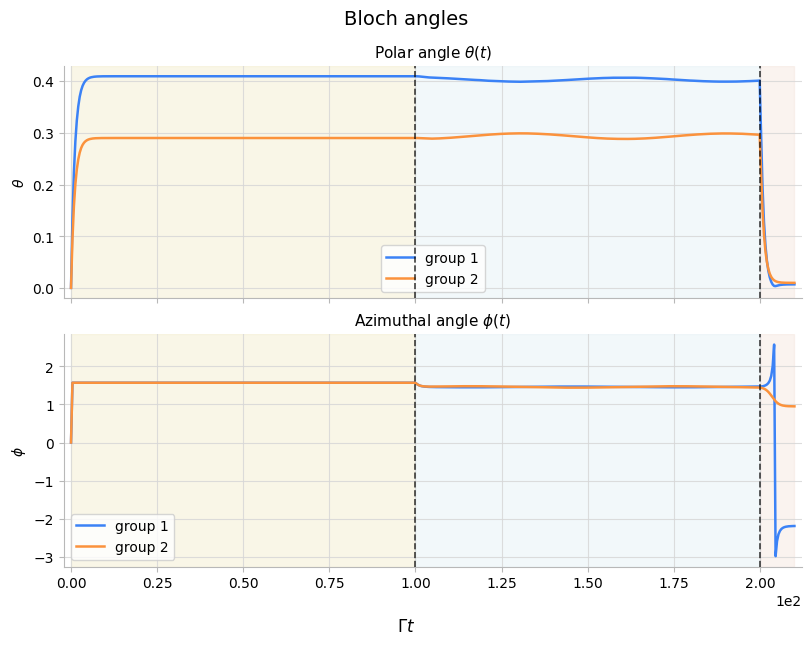

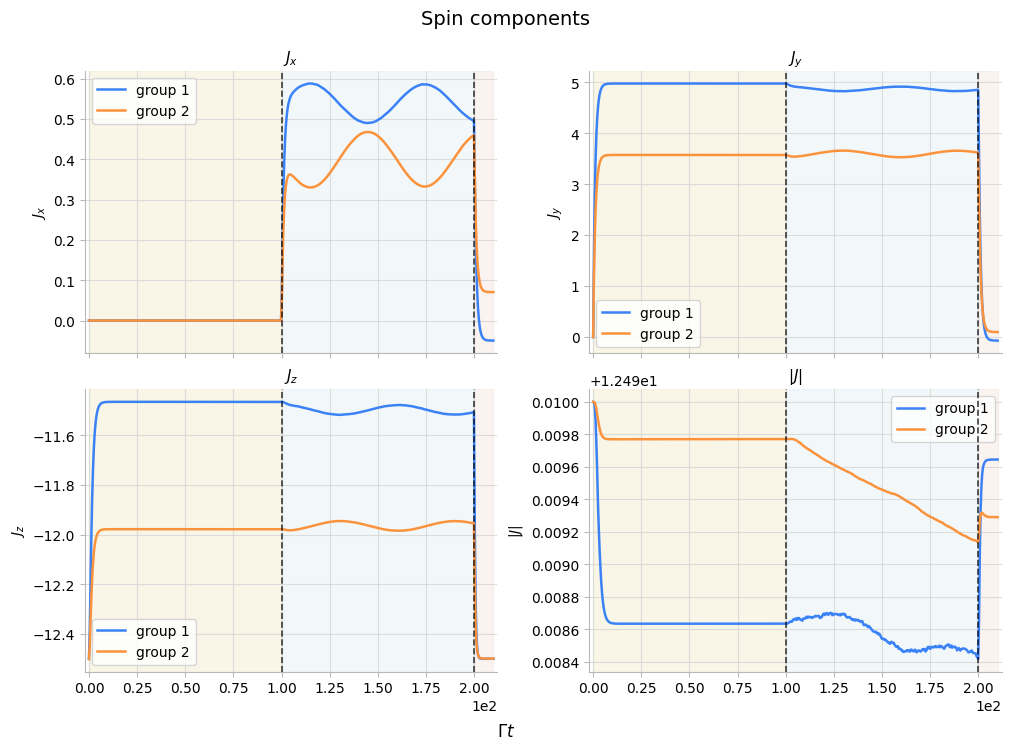

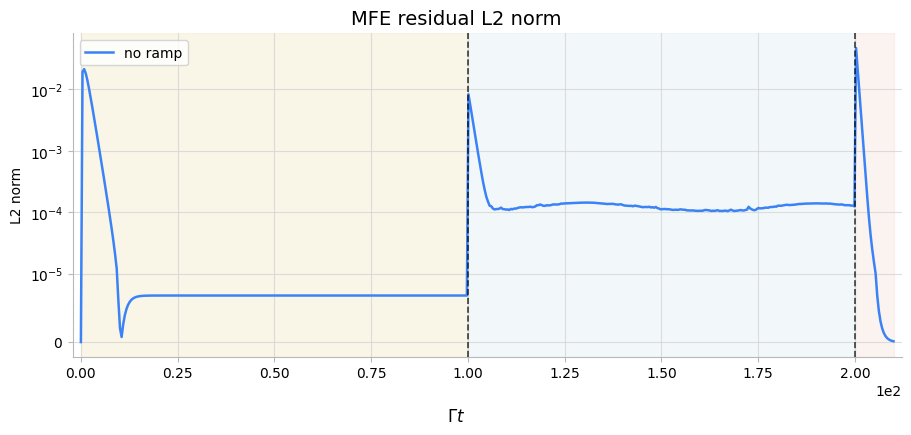

In [4]:
from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
    plot_mfe_residuals
)

# Plot spin angles

fig, axes = plot_bloch_angles(
    mcwf_moments.J.t,
    mcwf_moments.J.theta_groups,
    mcwf_moments.J.phi_groups,
    phase_protocol=mcwf_moments.metadata.phase_protocol,
    colour_family_index=None,
    shade_index=2,
    labels=[f"group {i}" for i in range(1, len(mcwf_moments.J.x_groups) + 1)],
    linestyle="-",

)


# Plot spin components
fig, axes = plot_spin_components(
    mcwf_moments.J.t,
    mcwf_moments.J.x_groups,
    mcwf_moments.J.y_groups,
    mcwf_moments.J.z_groups,
    mcwf_moments.J.length_groups,
    phase_protocol=mcwf_moments.metadata.phase_protocol,
    labels=[f"group {i}" for i in range(1, len(mcwf_moments.J.x_groups) + 1)],
    colour_family_index=None,
    shade_index=2,
    linestyle="-",
)

# plot mfe residuals
fig, axes = plot_mfe_residuals(
    mcwf_moments.mfe_residuals,
    phase_protocol=mcwf_moments.metadata.phase_protocol,
    show_components=False,
    label="no ramp",
    colour_family_index=None,
    shade_index=2,
    linestyle="-",
)
